note for final report: add OrderedDict to the seq_model so that the layers are clearly identified/explained.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv('../../data/project_data.csv')

In [8]:
# Reviewing dataset for null values
df = data
column_nan_count = df.isnull().sum()
print("Nan count per column:")
print(column_nan_count)

Nan count per column:
Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


In [9]:
# Reviewing shape of dataset
data.shape

(36238, 17)

In [10]:
# Reviewing data values in dataset
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,meal_plan_1,0,room_type1,224,2017-10-02,offline,0,0,0,65.00,0,not_canceled
1,INN00002,2,0,2,3,not_selected,0,room_type1,5,2018-11-06,online,0,0,0,106.68,1,not_canceled
2,INN00003,1,0,2,1,meal_plan_1,0,room_type1,1,2018-02-28,online,0,0,0,60.00,0,canceled
3,INN00004,2,0,0,2,meal_plan_1,0,room_type1,211,2018-05-20,online,0,0,0,100.00,0,canceled
4,INN00005,2,0,1,1,not_selected,0,room_type1,48,2018-04-11,online,0,0,0,94.50,0,canceled


In [11]:
# Preprocess/convert arrival_date column to season:
data['arrival_date'] = pd.to_datetime(data['arrival_date'])
data['month_number'] = data['arrival_date'].dt.month

def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Invalid Month'

data['season'] = data['month_number'].apply(month_to_season)
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,month_number,season
0,INN00001,2,0,1,2,meal_plan_1,0,room_type1,224,2017-10-02,offline,0,0,0,65.00,0,not_canceled,10,Autumn
1,INN00002,2,0,2,3,not_selected,0,room_type1,5,2018-11-06,online,0,0,0,106.68,1,not_canceled,11,Autumn
2,INN00003,1,0,2,1,meal_plan_1,0,room_type1,1,2018-02-28,online,0,0,0,60.00,0,canceled,2,Winter
3,INN00004,2,0,0,2,meal_plan_1,0,room_type1,211,2018-05-20,online,0,0,0,100.00,0,canceled,5,Spring
4,INN00005,2,0,1,1,not_selected,0,room_type1,48,2018-04-11,online,0,0,0,94.50,0,canceled,4,Spring


In [12]:
# Remove unneeded columns
data = data.drop(['Booking_ID', 'month_number', 'arrival_date'], axis=1)

In [13]:
# Remove existing column where target will be; identify target column
X = data.drop('booking_status', axis=1)
target_label = data['booking_status']

# Encode target with LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(target_label)

# Split dataset into training and test sets (75:25 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=123)  # split into train and test sets

In [14]:
# Review shapes of training and test inputs and target data
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((27178, 15), (9060, 15), (27178,), (9060,))

In [15]:
# Reviewing data values in training dataset
X_train.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,season
34711,1,0,2,2,meal_plan_1,0,room_type1,169,offline,0,0,0,63.50,0,Spring
12914,2,0,2,3,meal_plan_1,0,room_type1,2,online,0,0,0,130.00,1,Spring
27524,2,0,0,3,meal_plan_1,0,room_type1,271,offline,0,0,0,101.33,1,Autumn
14056,2,0,0,2,meal_plan_1,0,room_type1,32,offline,0,0,0,85.00,0,Autumn
16394,1,0,1,2,not_selected,0,room_type1,122,online,0,0,0,106.00,1,Summer


In [16]:
# One Hot Encode using scikit-learn OneHotEncoder on the training set
encoder = OneHotEncoder(handle_unknown='error')
encoder.fit(X_train[['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']])  # columns to fit

encoded_df = pd.DataFrame(encoder.transform(X_train[['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']]).toarray(),
                          columns=encoder.get_feature_names_out(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']))

X_train = pd.concat([X_train.drop(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season'], axis=1).reset_index(drop=True), encoded_df], axis=1)


In [17]:
# Review shape of dataset
X_train.shape

(27178, 31)

In [18]:
# Review columns within dataset
X_train.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'type_of_meal_plan_meal_plan_1',
       'type_of_meal_plan_meal_plan_2', 'type_of_meal_plan_meal_plan_3',
       'type_of_meal_plan_not_selected', 'room_type_reserved_room_type1',
       'room_type_reserved_room_type2', 'room_type_reserved_room_type3',
       'room_type_reserved_room_type4', 'room_type_reserved_room_type5',
       'room_type_reserved_room_type6', 'room_type_reserved_room_type7',
       'market_segment_type_aviation', 'market_segment_type_complementary',
       'market_segment_type_corporate', 'market_segment_type_offline',
       'market_segment_type_online', 'season_Autumn', 'season_Spring',
       'season_Summer', 'season_Winter'],
      dtype='object')

In [19]:
# Reviewing encoded_df dataset for null values
column_nan_count = encoded_df.isnull().sum()
print("NaN count per column:")
print(column_nan_count)

NaN count per column:
type_of_meal_plan_meal_plan_1        0
type_of_meal_plan_meal_plan_2        0
type_of_meal_plan_meal_plan_3        0
type_of_meal_plan_not_selected       0
room_type_reserved_room_type1        0
room_type_reserved_room_type2        0
room_type_reserved_room_type3        0
room_type_reserved_room_type4        0
room_type_reserved_room_type5        0
room_type_reserved_room_type6        0
room_type_reserved_room_type7        0
market_segment_type_aviation         0
market_segment_type_complementary    0
market_segment_type_corporate        0
market_segment_type_offline          0
market_segment_type_online           0
season_Autumn                        0
season_Spring                        0
season_Summer                        0
season_Winter                        0
dtype: int64


In [20]:
# Reviewing X_train dataset for null values
column_nan_count = X_train.isnull().sum()
print("NaN count per column:")
print(column_nan_count)

NaN count per column:
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
required_car_parking_space              0
lead_time                               0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
type_of_meal_plan_meal_plan_1           0
type_of_meal_plan_meal_plan_2           0
type_of_meal_plan_meal_plan_3           0
type_of_meal_plan_not_selected          0
room_type_reserved_room_type1           0
room_type_reserved_room_type2           0
room_type_reserved_room_type3           0
room_type_reserved_room_type4           0
room_type_reserved_room_type5           0
room_type_reserved_room_type6           0
room_type_reserved_room_type7           0
market_segment_type_aviation            0
market_segme

In [21]:
# Perform scaling using scikit-learn StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [22]:
# Convert scaled X_train data and existing y_train data to Torch tensors
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_tensor = torch.as_tensor(y_train, dtype=torch.float32)

In [23]:
# Review Torch tensor for scaled X_train data
X_train_tensor

tensor([[-1.6308, -0.2608,  1.3551,  ...,  1.9228, -0.6162, -0.4319],
        [ 0.2924, -0.2608,  1.3551,  ...,  1.9228, -0.6162, -0.4319],
        [ 0.2924, -0.2608, -0.9301,  ..., -0.5201, -0.6162, -0.4319],
        ...,
        [ 0.2924, -0.2608, -0.9301,  ..., -0.5201, -0.6162,  2.3153],
        [ 0.2924, -0.2608, -0.9301,  ..., -0.5201,  1.6229, -0.4319],
        [-1.6308, -0.2608, -0.9301,  ..., -0.5201, -0.6162,  2.3153]])

In [24]:
# Review Torch tensor for y_train data
y_train_tensor

tensor([1., 1., 0.,  ..., 1., 1., 0.])

In [25]:
# Review size of scaled X_train data Torch tensor
X_train_tensor.size()

torch.Size([27178, 31])

In [26]:
# Review size of y_train data Torch tensor
y_train_tensor.size()

torch.Size([27178])

In [27]:
# Divide training set into smaller training & validation datasets (80:20 ratio)
n_samples = X_train_tensor.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
train_indices, val_indices

# Assign values to tensor from indices
X_tr = X_train_tensor[train_indices]
y_tr = y_train_tensor[train_indices]
X_val = X_train_tensor[val_indices]
y_val = y_train_tensor[val_indices]

In [28]:
# One Hot Encode using scikit-learn OneHotEncoder on the test set
encoded_df = pd.DataFrame(encoder.transform(X_test[['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']]).toarray(),
                          columns=encoder.get_feature_names_out(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']))
X_test = pd.concat([X_test.drop(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season'], axis=1).reset_index(drop=True), encoded_df], axis=1)
X_test.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'type_of_meal_plan_meal_plan_1',
       'type_of_meal_plan_meal_plan_2', 'type_of_meal_plan_meal_plan_3',
       'type_of_meal_plan_not_selected', 'room_type_reserved_room_type1',
       'room_type_reserved_room_type2', 'room_type_reserved_room_type3',
       'room_type_reserved_room_type4', 'room_type_reserved_room_type5',
       'room_type_reserved_room_type6', 'room_type_reserved_room_type7',
       'market_segment_type_aviation', 'market_segment_type_complementary',
       'market_segment_type_corporate', 'market_segment_type_offline',
       'market_segment_type_online', 'season_Autumn', 'season_Spring',
       'season_Summer', 'season_Winter'],
      dtype='object')

In [29]:
# Perform scaling using same scaler identified in the training set scaling process
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

In [30]:
# Reviewing data values in test dataset
X_test_scaled.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,...,room_type_reserved_room_type7,market_segment_type_aviation,market_segment_type_complementary,market_segment_type_corporate,market_segment_type_offline,market_segment_type_online,season_Autumn,season_Spring,season_Summer,season_Winter
0,0.292397,-0.260756,0.212523,-0.852689,-0.178586,0.126311,-0.164492,-0.064272,-0.089512,0.436818,...,-0.064902,-0.056669,-0.105648,-0.243564,-0.63918,0.750474,1.348812,-0.520072,-0.616169,-0.431918
1,0.292397,-0.260756,1.355143,-0.852689,-0.178586,0.044983,-0.164492,-0.064272,-0.089512,-1.365187,...,-0.064902,-0.056669,-0.105648,-0.243564,-0.63918,0.750474,1.348812,-0.520072,-0.616169,-0.431918
2,0.292397,-0.260756,0.212523,-0.149177,-0.178586,0.021746,-0.164492,-0.064272,-0.089512,-1.469593,...,-0.064902,-0.056669,-0.105648,-0.243564,-0.63918,0.750474,-0.741393,1.922810,-0.616169,-0.431918
3,0.292397,-0.260756,-0.930097,0.554334,-0.178586,0.126311,-0.164492,-0.064272,-0.089512,-0.384739,...,-0.064902,-0.056669,-0.105648,-0.243564,-0.63918,0.750474,1.348812,-0.520072,-0.616169,-0.431918
4,0.292397,-0.260756,-0.930097,-0.149177,-0.178586,0.649138,-0.164492,-0.064272,-0.089512,1.720501,...,-0.064902,-0.056669,-0.105648,-0.243564,-0.63918,0.750474,1.348812,-0.520072,-0.616169,-0.431918


In [31]:
# Convert scaled X_test data and existing y_test data to Torch tensors
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)
y_test_tensor = torch.as_tensor(y_test, dtype=torch.float32)

In [32]:
# Define feedforward neural network
# Note 2 hidden layers, 2 activation functions
# Sigmoid function used for output layer

seq_model = nn.Sequential(
    nn.Linear(31, 20),
    nn.ReLU(),
    nn.Linear(20, 35),
    nn.ReLU(),
    nn.Linear(35, 1),
    nn.Sigmoid())
seq_model

Sequential(
  (0): Linear(in_features=31, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=35, bias=True)
  (3): ReLU()
  (4): Linear(in_features=35, out_features=1, bias=True)
  (5): Sigmoid()
)

In [33]:
# Establish empty arrays to capture losses for plotting later
train_losses = []
validation_losses = []

In [34]:
# Define the training loop
def training_loop(n_epochs, optimizer, model, loss_fn, X_tr, X_val, y_tr, y_val):
    for epoch in range(1, n_epochs + 1):
        X_tr_p = model(X_tr)
        loss_train = loss_fn(X_tr_p, y_tr.unsqueeze(1))
        train_losses.append(loss_train.item())  # for plotting purposes

        X_val_p = model(X_val)
        loss_val = loss_fn(X_val_p, y_val.unsqueeze(1))
        validation_losses.append(loss_val.item())  # for plotting purposes

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if epoch == 1 or epoch % 100 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"f" Validation loss {loss_val.item():.4f}")

In [35]:
# Ran the training loop for 1000 epochs and used the Adam optimizer.
optimizer = optim.Adam(seq_model.parameters(), lr=1e-3)
training_loop(
    n_epochs = 1000,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.BCELoss(),
    X_tr = X_tr,
    X_val = X_val,
    y_tr = y_tr,
    y_val = y_val)

Epoch 1, Training loss 0.6792, Validation loss 0.6790
Epoch 100, Training loss 0.4386, Validation loss 0.4432
Epoch 200, Training loss 0.3922, Validation loss 0.3942
Epoch 300, Training loss 0.3739, Validation loss 0.3778
Epoch 400, Training loss 0.3608, Validation loss 0.3833
Epoch 500, Training loss 0.3522, Validation loss 0.3768
Epoch 600, Training loss 0.3458, Validation loss 0.3734
Epoch 700, Training loss 0.3406, Validation loss 0.3698
Epoch 800, Training loss 0.3363, Validation loss 0.3673
Epoch 900, Training loss 0.3314, Validation loss 0.3653
Epoch 1000, Training loss 0.3270, Validation loss 0.3639


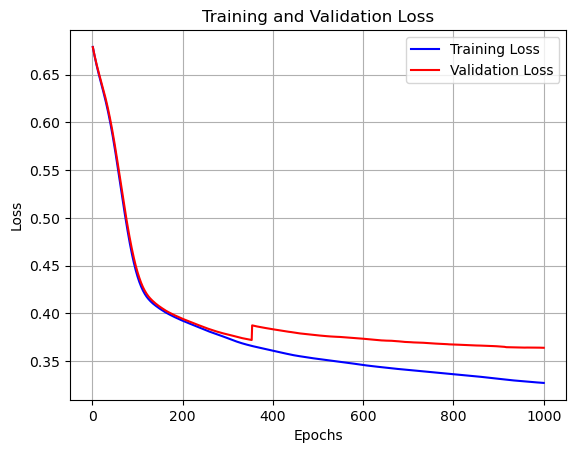

In [36]:
# Plot training and validation loss lines
epochs = range(1, len(train_losses) + 1)
plt.grid()
plt.plot(epochs, train_losses, 'b-', label='Training Loss')
plt.plot(epochs, validation_losses, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [37]:
# Calculate the fitted model predictions for the test set
seq_model(X_test_tensor).detach().numpy()

array([[0.98405355],
       [0.862676  ],
       [0.90178627],
       ...,
       [0.969133  ],
       [0.0160142 ],
       [0.5465721 ]], shape=(9060, 1), dtype=float32)

Create a data frame that combines the actual label values and the predicted probabilities of positive class membership.

In [38]:
# Create dataframe that combines actual label vaues vs predicted
# possibilities of a customer cancelling a reserved booking
p_1_actual = pd.DataFrame({'p_1': seq_model(X_test_tensor).detach().numpy().reshape(-1), 'actual': y_test})
p_1_actual.head()

,p_1,actual
0,0.984054,1
1,0.862676,1
2,0.901786,1
3,0.247755,1
4,0.141967,1


Calculate the information needed for the ROC curve.

In [39]:
# Calculation of data to produce an ROC curve
roc_data = pd.DataFrame({'threshold': np.arange(1, -0.01, -0.01), 'fpr': 0.0, 'tpr': 0.0})
for i in np.arange(1, -0.01, -0.01):

    over_threshold = p_1_actual[p_1_actual['p_1'] >= i]

    fp = len(over_threshold[over_threshold['actual']==0])
    actuals_0 = len(p_1_actual[p_1_actual['actual']==0])
    fpr = fp/actuals_0

    roc_data.loc[roc_data['threshold'] == i, 'fpr'] = fpr

    tp = len(over_threshold[over_threshold['actual']==1])
    actuals_1 = len(p_1_actual[p_1_actual['actual']==1])
    tpr = tp/actuals_1

    roc_data.loc[roc_data['threshold'] == i, 'tpr'] = tpr

roc_data

,threshold,fpr,tpr
0,1.000000e+00,0.000000,0.011254
1,9.900000e-01,0.004780,0.242212
2,9.800000e-01,0.006487,0.313652
3,9.700000e-01,0.010242,0.356222
4,9.600000e-01,0.015022,0.393411
...,...,...,...
96,4.000000e-02,0.807443,0.998532
97,3.000000e-02,0.833390,0.998858
98,2.000000e-02,0.870263,0.999348
99,1.000000e-02,0.902356,0.999674


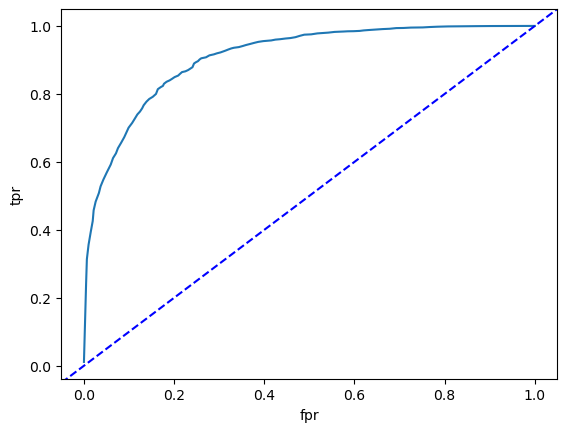

In [40]:
# Plot the ROC curve
# Expecting a curve that approaches top-left corner of graph and then
# curves out to the right
roc = sns.lineplot(x='fpr', y='tpr', data=roc_data)
plt.xlim(-0.05, 1.05)

xlims = roc.get_xlim()
ylims = roc.get_ylim()

min_val = min(xlims[0], ylims[0])
max_val = max(xlims[1], ylims[1])

roc.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='blue')

roc.set_xlim(xlims)
roc.set_ylim(ylims)

plt.show()

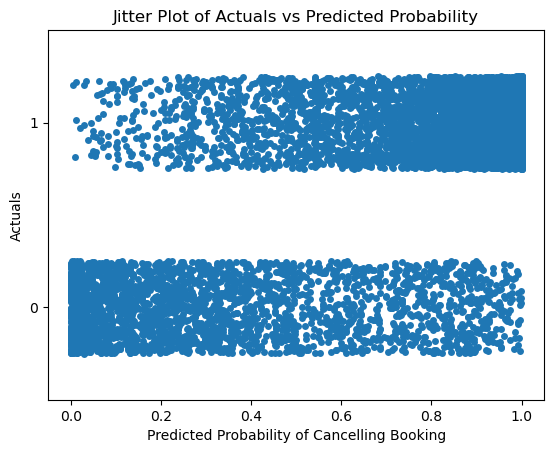

In [41]:
# Plot jitter plot to visualize predicted probabilities of cancelled bookings
# Expecting a balanced class membership
p_1_actual['actual'] = p_1_actual['actual'].astype(str)

# Create a jitter plot using stripplot
sns.stripplot(x='p_1', y='actual', data=p_1_actual, jitter=0.25)

# Customize the plot (optional)
plt.title('Jitter Plot of Actuals vs Predicted Probability')
plt.xlabel('Predicted Probability of Cancelling Booking')
plt.ylabel('Actuals')

# Display the plot
plt.show()